### Predict the salary based on the years of experience using the Simple Linear Regression


#### Step 1:--- Import all the necessary libraries

In [1652]:
import numpy  as  np
import pandas as  pd
import matplotlib.pyplot as plt
import seaborn    as  sns

from   sklearn.model_selection import train_test_split
from   sklearn.preprocessing   import StandardScaler
from   sklearn.linear_model    import LinearRegression
from   sklearn.metrics         import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

#### Step 2:--- Load the dataset

In [1653]:
df = pd.read_csv('Salary_Data.csv')

In [1654]:
df

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


#### OBSERVATIONS:

1. The dataset contains two columns:--

   (a.)  YearsExperience   -------> Years of experience of the employee

   (b.)  Salary            -------> Salary earned by the employee

#### Step 3:-- Perform the Feature Engineering

In [1655]:
print("Total length of the dataset is:", len(df))

Total length of the dataset is: 30


In [1656]:
### Shape of the dataset

print(df.shape)

(30, 2)


In [1657]:
### get the top five rows of the dataset

print(df.head())

   YearsExperience   Salary
0              1.1  39343.0
1              1.3  46205.0
2              1.5  37731.0
3              2.0  43525.0
4              2.2  39891.0


In [1658]:
### get the last five rows of the dataset

print(df.tail())

    YearsExperience    Salary
25              9.0  105582.0
26              9.5  116969.0
27              9.6  112635.0
28             10.3  122391.0
29             10.5  121872.0


In [1659]:
### get the columns used in the dataset

df.columns

Index(['YearsExperience', 'Salary'], dtype='object')

In [1660]:
### get the information about the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [1661]:
#### get the statistical summary about the dataset

df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [1662]:
#### Check for any NULL records used in the dataframe

df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

### OBSERVATIONS:

1.  There are no NULL records used in the dataset.

In [1663]:
#### Check for any duplicate records used in the dataset

df[df.duplicated()]

,YearsExperience,Salary


#### OBSERVATIONS:

1.  There are no duplicate records left in the dataset.

In [1664]:
### get the correlation between all the numerical columns used in the dataset

df.corr()

,YearsExperience,Salary
YearsExperience,1.000000,0.978242
Salary,0.978242,1.000000


<Axes: >

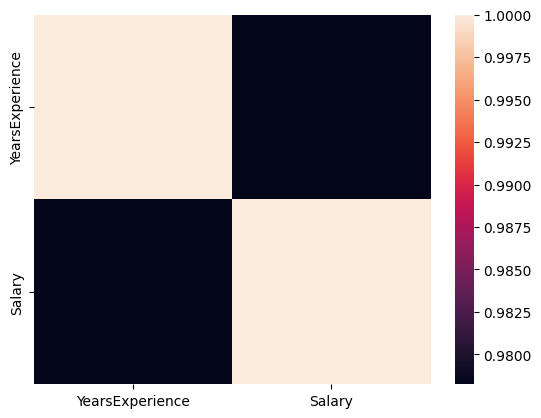

In [1665]:
### perform the graphical representation of all the columns used in the dataset

sns.heatmap(df.corr())

#### OBSERVATIONS:

1.  There is a high correlation between the 'Years of experience' and the 'Salary'.

### Step 4:-- Divide the dataset into independent and dependent variables

In [1666]:
### independent variables

X = df[['YearsExperience']]

### dependent variables

Y = df['Salary']

In [1667]:
X

,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2
5,2.9
6,3.0
7,3.2
8,3.2
9,3.7


In [1668]:
Y

0      39343.0
1      46205.0
2      37731.0
3      43525.0
4      39891.0
5      56642.0
6      60150.0
7      54445.0
8      64445.0
9      57189.0
10     63218.0
11     55794.0
12     56957.0
13     57081.0
14     61111.0
15     67938.0
16     66029.0
17     83088.0
18     81363.0
19     93940.0
20     91738.0
21     98273.0
22    101302.0
23    113812.0
24    109431.0
25    105582.0
26    116969.0
27    112635.0
28    122391.0
29    121872.0
Name: Salary, dtype: float64

#### OBSERVATIONS:

1.  The entire dataset is divided into the independent and dependent variables.

#### Step 5:-- Divide the independent and dependent variables into training and testing data

In [1669]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [1670]:
X_train

,YearsExperience
28,10.3
24,8.7
12,4.0
0,1.1
4,2.2
16,5.1
5,2.9
13,4.1
11,4.0
22,7.9


In [1671]:
X_test

,YearsExperience
27,9.6
15,4.9
23,8.2
17,5.3
8,3.2
9,3.7


In [1672]:
print("Shape of the input training data is:", X_train.shape)
print("Shape of the input testing  data is:", X_test.shape)

Shape of the input training data is: (24, 1)
Shape of the input testing  data is: (6, 1)


In [1673]:
Y_train

28    122391.0
24    109431.0
12     56957.0
0      39343.0
4      39891.0
16     66029.0
5      56642.0
13     57081.0
11     55794.0
22    101302.0
1      46205.0
2      37731.0
25    105582.0
3      43525.0
21     98273.0
26    116969.0
18     81363.0
29    121872.0
20     91738.0
7      54445.0
10     63218.0
14     61111.0
19     93940.0
6      60150.0
Name: Salary, dtype: float64

In [1674]:
Y_test

27    112635.0
15     67938.0
23    113812.0
17     83088.0
8      64445.0
9      57189.0
Name: Salary, dtype: float64

In [1675]:
print("Shape of the output training data is:", Y_train.shape)
print("Shape of the output testing  data is:", Y_test.shape)

Shape of the output training data is: (24,)
Shape of the output testing  data is: (6,)


#### Step 6:-- Train the model using linear regression

In [1676]:
from sklearn.linear_model import LinearRegression

### use an object for linear regression

model = LinearRegression()

### using the object of linear regression train the model

model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### OBSERVATIONS:

1.  The linear regression model has been trained using the training data.

### Step 7:-- Predict the model

In [1677]:
Y_pred = model.predict(X_test)

In [1678]:
Y_pred

array([115790.21011287,  71498.27809463, 102596.86866063,  75267.80422384,
        55477.79204548,  60189.69970699])

#### OBSERVATIONS:

1.  The predicted salary is obtained for the given input test data of (Years of experience).

#### Step 8:-- Compare the Actual vs Predicted Results and store the Residual in a dataframe

In [1679]:
results = pd.DataFrame({
    'Actual Results'         :          Y_test               ,
    'Predicted Results'      :          Y_pred               ,
    'Residual'               :          (Y_test - Y_pred)
})

In [1680]:
results

,Actual Results,Predicted Results,Residual
27,112635.0,115790.210113,-3155.210113
15,67938.0,71498.278095,-3560.278095
23,113812.0,102596.868661,11215.131339
17,83088.0,75267.804224,7820.195776
8,64445.0,55477.792045,8967.207955
9,57189.0,60189.699707,-3000.699707


#### OBSERVATIONS:

1.  The Actual Results is compared with the Predicted results and the Residual is shown as the result in the dataframe.

#### Step 9:---  Compute the Model Parameters

In [1681]:
print("Slope of the model is:",     model.coef_[0])
print("Intercept of the model is:", model.intercept_)

Slope of the model is: 9423.815323030976
Intercept of the model is: 25321.583011776813


#### Step 10:--- Evaluate the Regression Metrics

In [1682]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error


mae = mean_absolute_error(Y_test, Y_pred)

print("Mean Absolute Error of the model is:", mae)

Mean Absolute Error of the model is: 6286.453830757749


In [1683]:
mse = mean_squared_error(Y_test, Y_pred)

print("Mean Squared Error of the model is:", mse)

Mean Squared Error of the model is: 49830096.85590839


In [1684]:
r2 = r2_score(Y_test, Y_pred)

print("R2 Score of the model is:", r2)

R2 Score of the model is: 0.9024461774180497


In [1685]:
rmse = root_mean_squared_error(Y_test, Y_pred)

print("Root Mean Squared Error of the model is:", rmse)

Root Mean Squared Error of the model is: 7059.04362190151


#### OBSERVATIONS:

As the R2 Score of the model is 0.9. It is very high. So the model is working fine. But it can be improved.

#### Step 11: Improve the performance of the model using Ridge and Lasso

In [1686]:
### Train the model using Ridge Regression

from sklearn.linear_model import Ridge, Lasso


### use the object of Ridge to train the model

ridge = Ridge(alpha=1.0)

ridge.fit(X_train, Y_train)

### predict the model for Ridge regression

Y_pred_ridge = ridge.predict(X_test)

print(Y_pred_ridge)

[115582.53212304  71511.80952173 102455.08283754  75262.50931758
  55571.33538934  60259.71013416]


#### OBSERVATIONS:

1.  The ridge model is called using the alpha = 1 as the regularization parameter to add the penalty into the model.

2.  Then the model is trained using the training data.

3.  The output is predicted using the ridge regression using the input testing data.

In [1687]:
### use the object of Lasso, train the model

lasso = Lasso(alpha=0.1)

### use the object of lasso, train the model

lasso.fit(X_train, Y_train)

### use the object of lasso, predict the model

Y_pred_lasso = lasso.predict(X_test)

print(Y_pred_lasso)

[115790.15695723  71498.28155803 102596.83237023  75267.8028686
  55477.8159881   60189.71762632]


#### Step 12:-- Again evaluate the regression metrics

In [1688]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

print("=======================Ridge Regression=============================================================")
maeridge = mean_absolute_error(Y_test, Y_pred_ridge)

print("Mean Absolute Error of the model is:", maeridge)


mseridge = mean_squared_error(Y_test, Y_pred_ridge)

print("Mean Squared Error of the model is:", mseridge)



r2scoreridge = r2_score(Y_test, Y_pred_ridge)

print("R2 Score of the model is:", r2scoreridge)


rmseridge = root_mean_squared_error(Y_test, Y_pred_ridge)

print("Root Mean Squared Error of the model is:", rmseridge)

=======================Ridge Regression=============================================================
Mean Absolute Error of the model is: 6274.687372409958
Mean Squared Error of the model is: 49974852.71999631
R2 Score of the model is: 0.9021627846740267
Root Mean Squared Error of the model is: 7069.289407005227


In [1689]:
print("=======================Lasso Regression=============================================================")
maelasso = mean_absolute_error(Y_test, Y_pred_lasso)

print("Mean Absolute Error of the model is:", maelasso)


mselasso = mean_squared_error(Y_test, Y_pred_lasso)

print("Mean Squared Error of the model is:", mselasso)



r2scorelasso = r2_score(Y_test, Y_pred_lasso)

print("R2 Score of the model is:", r2scorelasso)


rmselasso = root_mean_squared_error(Y_test, Y_pred_lasso)

print("Root Mean Squared Error of the model is:", rmselasso)

=======================Lasso Regression=============================================================
Mean Absolute Error of the model is: 6286.450819106421
Mean Squared Error of the model is: 49830130.61850805
R2 Score of the model is: 0.9024461113200314
Root Mean Squared Error of the model is: 7059.0460133440165


#### OBSERVATIONS:

1.  After applying Ridge and Lasso Regression, there is not much difference in the r2 score as compared to the original one.

### Step 13:--- Perform the Hyper Parameter Tuning to improve the performance 

In [1690]:
#### use the corss validation instead of using the alpha

from sklearn.model_selection import GridSearchCV

ridge_params = {"alpha" : [0.01, 0.1, 1, 10, 100]}

lasso_params = {"alpha" : [0.001, 0.01, 0.1, 1, 10, 100]}


#### create an object for Grid Serach CV for both Ridge and Lasso Regression

ridge_cv = GridSearchCV(Ridge(), ridge_params, cv=5)

lasso_cv = GridSearchCV(Lasso(), lasso_params, cv=5)

In [1691]:
### use the object for Grid Search CV to train the model

ridge_cv.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter indexes are also d

In [1692]:
lasso_cv.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Lasso()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter indexes are also

In [1693]:
#### Get the best parameters for Ridge and Lasso Regression

print("Best Parameters for Ridge Regression is:", ridge_cv.best_params_)

print("Best Parameters for Lasso Regression is:", lasso_cv.best_params_)

Best Parameters for Ridge Regression is: {'alpha': 1}
Best Parameters for Lasso Regression is: {'alpha': 100}


In [1694]:
#### Get the best estimator for Ridge and Lasso Regression

best_ridge = ridge_cv.best_estimator_
print("Best Estimator for Ridge Regression is:",best_ridge)

best_lasso = lasso_cv.best_estimator_
print("Best Estimator for Lasso Regression is:",best_lasso)

Best Estimator for Ridge Regression is: Ridge(alpha=1)
Best Estimator for Lasso Regression is: Lasso(alpha=100)


In [1695]:
#### using the best estimator for Ridge and Lasso Regression, predict the model

Y_pred_ridge = best_ridge.predict(X_test)


Y_pred_lasso = best_lasso.predict(X_test)

In [1696]:
Y_pred_ridge

array([115582.53212304,  71511.80952173, 102455.08283754,  75262.50931758,
        55571.33538934,  60259.71013416])

In [1697]:
Y_pred_lasso

array([115737.05446697,  71501.74149365, 102560.57826215,  75266.44898074,
        55501.73467352,  60207.61903238])

#### Step 14:--- Perform the Evaluation of the Model

In [1698]:
r2score_ridge = r2_score(Y_test, Y_pred_ridge)

print("R2 Score of the Hyper Parameterized Ridge Regression Model is:", r2score_ridge)

R2 Score of the Hyper Parameterized Ridge Regression Model is: 0.9021627846740267


In [1699]:
r2score_lasso = r2_score(Y_test, Y_pred_lasso)

print("R2 Score of the Hyper Parameterized Lasso Regression Model is:", r2score_lasso)

R2 Score of the Hyper Parameterized Lasso Regression Model is: 0.9023784330643461


#### OBSERVATIONS:

1.  After applying Hyper Parameter Tuning, there is not much difference in the r2 score as compared to the original one.

### Step 15:--- Dump the model

In [1700]:
import joblib

#### Dump the model

joblib.dump(best_ridge, "salary_model.pkl")

['salary_model.pkl']